In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))

In [2]:
import setup_path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import string
from src.utils.graphs import error_line_graph

In [3]:
labels = ['SV_WS_LR', 'UP_WS_LR', 'SV_WS', 'UP_WS', 'SV_LR', 'UP_LR', 'SV', 'UP']
markers = ['*', '*', '*', '*', '.', '.', '.', '.']
lss = ['--', '-', '--', '-', '--', '-', '--', '-']
files = ["data_p9_r0-2.txt", "data_p9_r0-5.txt", "data_p9_r0-8.txt"]
data_dict = defaultdict(list)

for f in files:
    with open(f, "r") as file:
        loaded_data = eval(file.read())
    
    n_assets = [loaded_data[label]['n_assets'] for label in labels]
    data_dict['r_total'].append([loaded_data[label]['r'] for label in labels])
    data_dict['probs'].append([loaded_data[label]['probs'] for label in labels])
    data_dict['qaoa_FR'].append([loaded_data[label]['qaoa_FR'] for label in labels])
    data_dict['t_total'].append([loaded_data[label]['t_total'] for label in labels])
    data_dict['n_fev'].append([loaded_data[label]['n_fev'] for label in labels])
    success_c = [loaded_data[label]['success_counter'] for label in labels]

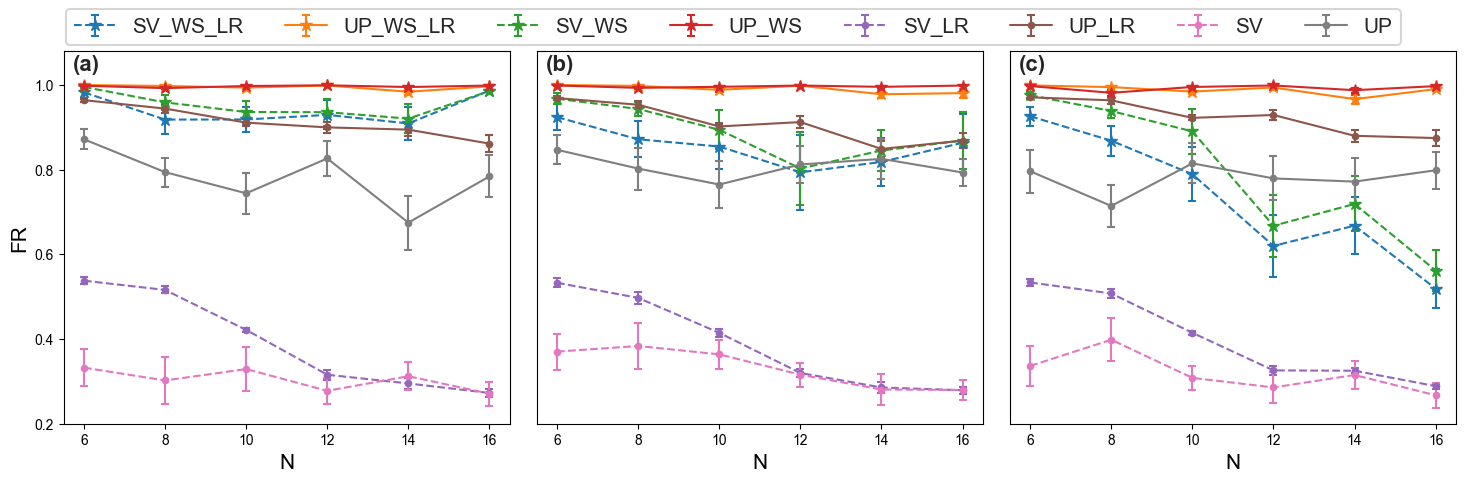

In [4]:
x = n_assets
raw_data = data_dict['qaoa_FR']
labels = labels
title = 'FR_0-5'
y_label = 'FR'
x_label = 'N'
y_lim = [0.2, 1.08]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
for i in range(3):
    error_line_graph(axs[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    axs[i].set_xlabel(x_label, fontsize=15)
    axs[i].set_ylim(y_lim)
    if i>0:
        axs[i].tick_params(labelleft=False)
        axs[i].tick_params(left=False, labelleft=False)
axs[0].set_ylabel(y_label, fontsize=15)

letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs, letters):
    ax.text(0.02, 0.99, letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

fig.legend(
    labels,
    frameon=True,
    fontsize=15,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # space for legend
plt.savefig('FR.pdf')
plt.show()

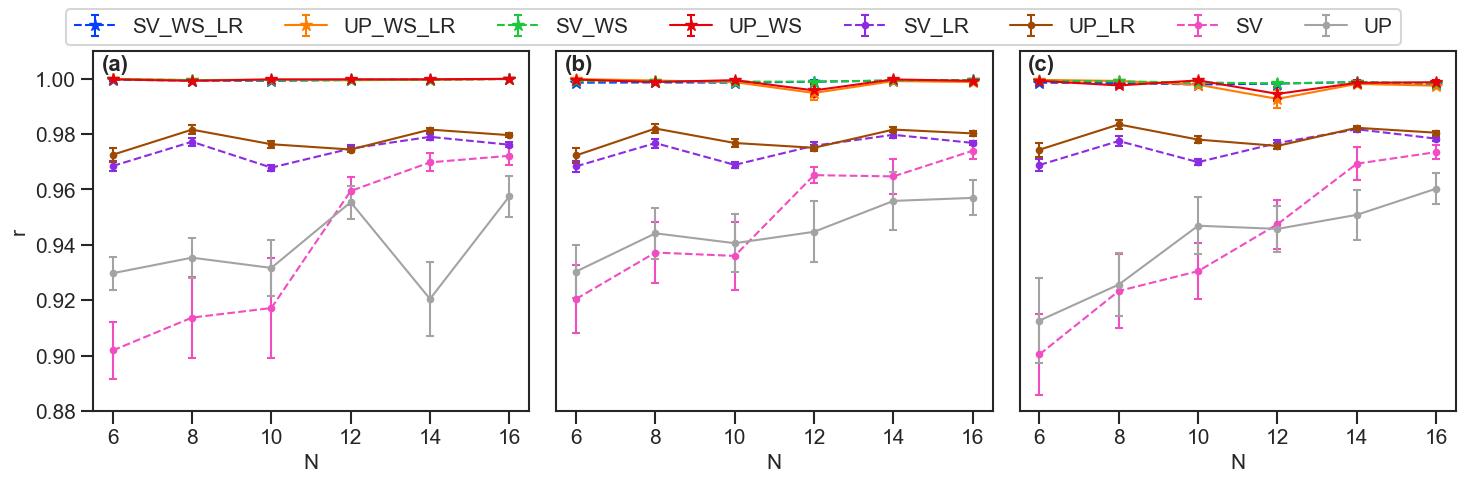

In [5]:
x = n_assets
raw_data = data_dict['r_total']
labels = labels
y_label = 'r'
x_label = 'N'
y_lim = [0.88, 1.01]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    error_line_graph(axs[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    axs[i].set_xlabel(x_label, fontsize=15)
    axs[i].set_ylim(y_lim)
    if i>0:
        axs[i].tick_params(labelleft=False)
        axs[i].tick_params(left=False, labelleft=False)
axs[0].set_ylabel(y_label, fontsize=15)

letters = ['(a)', '(b)', '(c)']
for ax, letter in zip(axs, letters):
    ax.text(
        0.02, 0.99,          # relative coordinades to the axis (x=2%, y=95%)
        letter,
        transform=ax.transAxes,  # use relative coordinades to the axis
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )

fig.legend(
    labels,
    frameon=True,
    fontsize=15,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=8
)

#plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio arriba para la leyenda
plt.savefig('r.pdf')
plt.show()

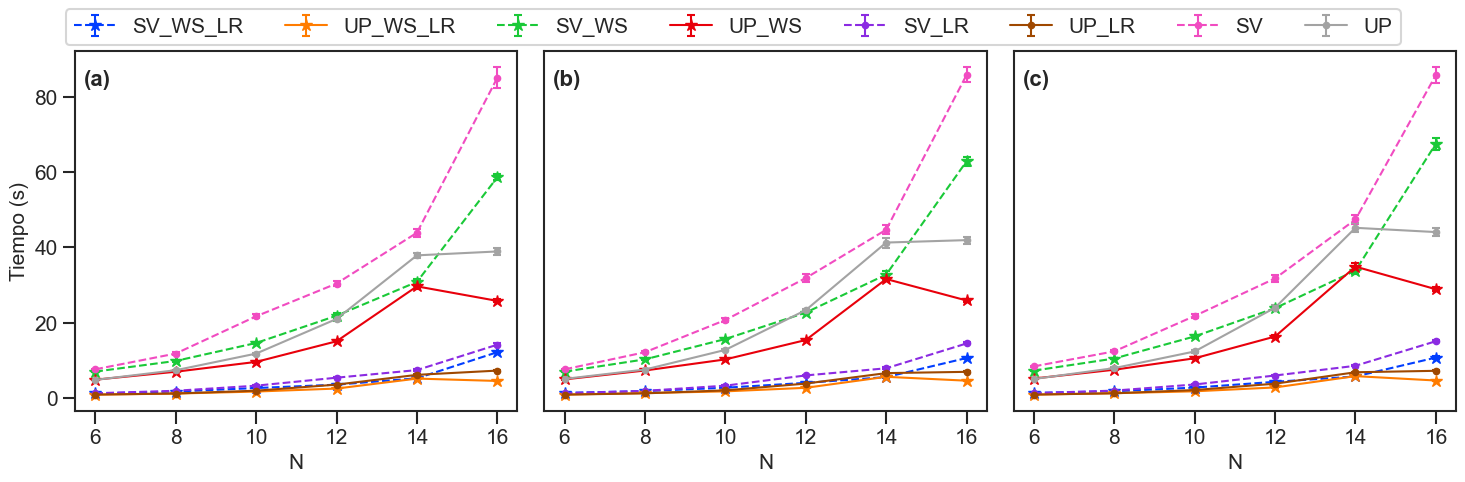

In [6]:
x = n_assets
raw_data = data_dict['t_total']
labels = labels
title = None
y_label = 'Tiempo (s)'
x_label = 'N'
y_lim = None

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    error_line_graph(axs[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    axs[i].set_xlabel(x_label, fontsize=15)
    axs[i].set_ylim(y_lim)
    if i>0:
        axs[i].tick_params(labelleft=False)
        axs[i].tick_params(left=False, labelleft=False)
axs[0].set_ylabel(y_label, fontsize=15)

letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs, letters):
    ax.text(0.02, 0.95, letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

fig.legend(
    labels,
    frameon=True,
    fontsize=15,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # space for legend
plt.savefig('t.pdf')
plt.show()

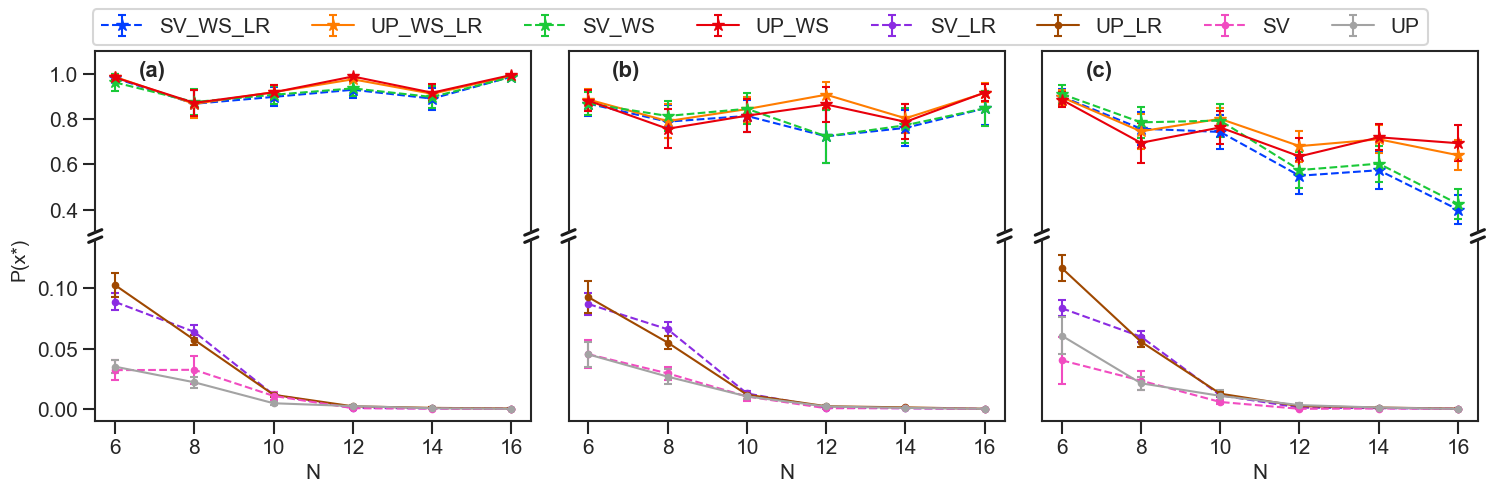

In [7]:
x = n_assets
raw_data = data_dict['probs']
labels = labels
title = 'FR_0-5'
y_label = 'P(x*)'
x_label = 'N'
y1_lim = [0.3, 1.1]
y2_lim = [-0.01, 0.14]

fig, (axs1, axs2) = plt.subplots(2, 3, figsize=(15, 5))
for i in range(3):
    error_line_graph(axs2[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    error_line_graph(axs1[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    axs2[i].set_xlabel(x_label, fontsize=15)
    axs1[i].set_ylim(y1_lim)
    axs2[i].set_ylim(y2_lim)
    # hide spines between broken axes
    axs1[i].spines['bottom'].set_visible(False)
    axs2[i].spines['top'].set_visible(False)

    # hide tick labels between panels
    axs1[i].tick_params(labelbottom=False, labeltop=False, bottom=False, which='both', axis='x')

    # draw diagonal lines to indicate break
    d = .015  # diagonal size in axes coordinates 
    kwargs = dict(transform=axs1[i].transAxes, color='k', clip_on=False)
    axs1[i].plot((-d, +d), (-d, +d), **kwargs)
    axs1[i].plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=axs2[i].transAxes)
    axs2[i].plot((-d, +d), (1 - d, 1 + d), **kwargs)
    axs2[i].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    if i>0:
        axs1[i].tick_params(labelleft=False)
        axs1[i].tick_params(left=False, labelleft=False)
        axs2[i].tick_params(labelleft=False)
        axs2[i].tick_params(left=False, labelleft=False)
fig.text(0, 0.5, y_label, va='center', rotation='vertical', fontsize=14)

letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs1, letters):
    ax.text(0.1, 0.95, letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
from collections import OrderedDict
handles, labels = [], []
for ax in axs1.tolist() + axs2.tolist():
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

handles_labels = OrderedDict(zip(labels, handles))

fig.legend(
    handles_labels.values(),
    handles_labels.keys(),
    frameon=True,
    fontsize=15,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # space for legend
plt.subplots_adjust(hspace=0.04)
plt.savefig('probs.pdf')
plt.show()

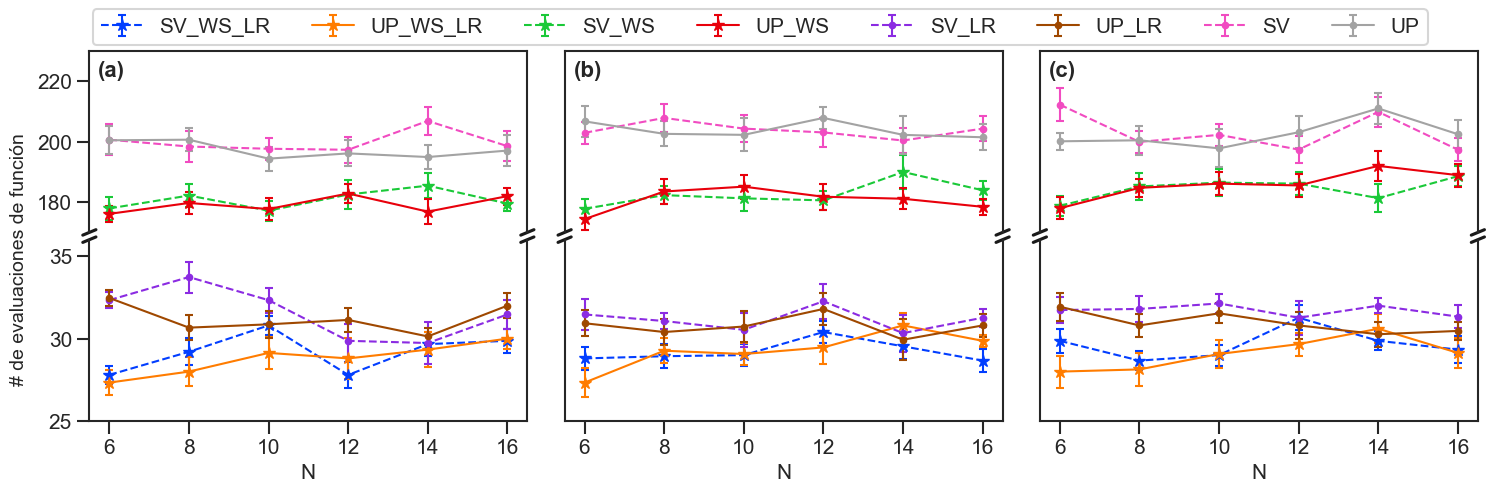

In [8]:
x = n_assets
raw_data = data_dict['n_fev']
labels = labels
title = 'FR_0-5'
y_label = '# de evaluaciones de función'
x_label = 'N'
y1_lim = [170, 230]
y2_lim = [25, 36]

fig, (axs1, axs2) = plt.subplots(2, 3, figsize=(15, 5))
for i in range(3):
    error_line_graph(axs2[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    error_line_graph(axs1[i], x, raw_data[i], labels, title, x_label, y_label, markers, lss)
    axs2[i].set_xlabel(x_label, fontsize=15)
    axs1[i].set_ylim(y1_lim)
    axs2[i].set_ylim(y2_lim)
    # hide spines between broken axes
    axs1[i].spines['bottom'].set_visible(False)
    axs2[i].spines['top'].set_visible(False)

    # hide tick labels between panels
    axs1[i].tick_params(labelbottom=False, labeltop=False, bottom=False, which='both', axis='x')

    # draw diagonal lines to indicate break
    d = .015  # diagonal size in axes coordinates 
    kwargs = dict(transform=axs1[i].transAxes, color='k', clip_on=False)
    axs1[i].plot((-d, +d), (-d, +d), **kwargs)
    axs1[i].plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=axs2[i].transAxes)
    axs2[i].plot((-d, +d), (1 - d, 1 + d), **kwargs)
    axs2[i].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    if i>0:
        axs1[i].tick_params(labelleft=False)
        axs1[i].tick_params(left=False, labelleft=False)
        axs2[i].tick_params(labelleft=False)
        axs2[i].tick_params(left=False, labelleft=False)
fig.text(0, 0.5, y_label, va='center', rotation='vertical', fontsize=14)

letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs1, letters):
    ax.text(0.02, 0.95, letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
from collections import OrderedDict
handles, labels = [], []
for ax in axs1.tolist() + axs2.tolist():
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

handles_labels = OrderedDict(zip(labels, handles))

fig.legend(
    handles_labels.values(),
    handles_labels.keys(),
    frameon=True,
    fontsize=15,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # space for legend
plt.subplots_adjust(hspace=0.04)
plt.savefig('n_fev.pdf')
plt.show()